In [ ]:
import yfinance as yf
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout , GRU
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
df = yf.download("TSLA",start ="2010-01-01",end="2025-01-01")

/tmp/ipykernel_413/13853459.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("TSLA",start ="2010-01-01",end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


In [ ]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2010-06-29,1.592667,1.666667,1.169333,1.266667,281494500
2010-06-30,1.588667,2.028000,1.553333,1.719333,257806500
2010-07-01,1.464000,1.728000,1.351333,1.666667,123282000
2010-07-02,1.280000,1.540000,1.247333,1.533333,77097000
2010-07-06,1.074000,1.333333,1.055333,1.333333,103003500


In [ ]:
df.shape

(3652, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3652 entries, 2010-06-29 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   3652 non-null   float64
 1   (High, TSLA)    3652 non-null   float64
 2   (Low, TSLA)     3652 non-null   float64
 3   (Open, TSLA)    3652 non-null   float64
 4   (Volume, TSLA)  3652 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 171.2 KB


In [ ]:
df.isna().sum()

,,0
Price,Ticker,
Close,TSLA,0
High,TSLA,0
Low,TSLA,0
Open,TSLA,0
Volume,TSLA,0


In [ ]:
df = df.sort_values(by="Date").reset_index(drop=True)

#create indicators

## MA10

In [ ]:
df['MA10']=df['Close'].rolling(10).mean()

In [ ]:
df['MA20']=df['Close'].rolling(20).mean()

##RSI

In [ ]:
delta = df['Close'].diff()

In [ ]:
gain = delta.clip(lower=0)
loss = -1*delta.clip(upper=0)

In [ ]:
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

In [ ]:
rs = avg_gain/avg_loss
df['RSI'] = 100 - (100/(1+rs))

##MACD

In [ ]:
ema12 = df['Close'].ewm(span=12,adjust=False).mean()
ema26 = df['Close'].ewm(span=26,adjust=False).mean()

In [ ]:
df['MACD']=ema12-ema26
df['Signal']=df['MACD'].ewm(span=9,adjust=False).mean()

#SCALING

In [ ]:
df.head()

Price,Close,High,Low,Open,Volume,MA10,MA20,RSI,MACD,Signal
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA,,,,,
0,1.592667,1.666667,1.169333,1.266667,281494500,NaN,NaN,NaN,0.000000,0.000000
1,1.588667,2.028000,1.553333,1.719333,257806500,NaN,NaN,NaN,-0.000319,-0.000064
2,1.464000,1.728000,1.351333,1.666667,123282000,NaN,NaN,NaN,-0.010510,-0.002153
3,1.280000,1.540000,1.247333,1.533333,77097000,NaN,NaN,NaN,-0.033053,-0.008333
4,1.074000,1.333333,1.055333,1.333333,103003500,NaN,NaN,NaN,-0.066772,-0.020021


In [ ]:
features = ['Close','MA10','MA20','RSI','MACD','Signal']

In [ ]:
scaler = MinMaxScaler()

In [ ]:
scaled_featurs = scaler.fit_transform(df[features].dropna())
df_scaled = pd.DataFrame(scaled_featurs,columns=features,index=df[features].dropna().index)

In [ ]:
df_scaled.head()

,Close,MA10,MA20,RSI,MACD,Signal
19,0.000411,0.000293,0.000095,0.732018,0.383600,0.389051
20,0.000435,0.000307,0.000069,0.682898,0.383650,0.389141
21,0.000383,0.000313,0.000042,0.658148,0.383663,0.389216
22,0.000326,0.000303,0.000026,0.653547,0.383644,0.389272
23,0.000462,0.000288,0.000039,0.649086,0.383712,0.389332


#Windowing

In [ ]:
window = 30

In [ ]:
x = []
y = []

In [ ]:
df_scaled = df_scaled.dropna().reset_index(drop=True)

df_scaled = df_scaled[features].values

In [ ]:
for i in range(len(df_scaled) - window):
    x.append(df_scaled[i:i+window])
    y.append(df_scaled[i+window][0])

x = np.array(x)
y = np.array(y)

print("x shape:", x.shape)
print("y shape:", y.shape)

x shape: (3603, 30, 6)
y shape: (3603,)


# Train / Test Split


In [ ]:
train_size = int(len(x)*0.8)

x_train = x[:train_size]
x_test = x[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(x_train.shape, x_test.shape)

(2882, 30, 6) (721, 30, 6)


  Early Stop

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

#models

##LSTM


In [ ]:
model = Sequential()

model.add(LSTM(64,return_sequences=True,input_shape=(x_train.shape[1],x_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam',loss='mse')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(x_train,y_train,epochs=50,batch_size=32,validation_data=(x_test,y_test),callbacks=[early_stop])

Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0029 - val_loss: 0.0053
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0011 - val_loss: 0.0027
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.2191e-04 - val_loss: 0.0027
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0010 - val_loss: 0.0027
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.6194e-04 - val_loss: 0.0029
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.3013e-04 - val_loss: 0.0075
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0012 - val_loss: 0.0017
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.8773e-04 - val_loss: 0.0015
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.0129e-04 - val_loss: 0.0015
Epoch 10/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 6.1329e-04 - val_loss: 0.0039
Epoch 11/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 7.6365e-04 - val_loss: 0.0018
Epoch 12/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9

In [ ]:
prediction = model.predict(x_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


Inverse Scaling

In [ ]:
dummy = np.zeros((len(prediction), x.shape[2]))

dummy[:,0] = prediction.flatten()

pred_real = scaler.inverse_transform(dummy)[:,0]

In [ ]:
dummy2 = np.zeros((len(y_test), x.shape[2]))

dummy2[:,0] = y_test

y_real = scaler.inverse_transform(dummy2)[:,0]

Evalution of LSTM

In [ ]:

rmse = np.sqrt(mean_squared_error(y_real, pred_real))
mae = mean_absolute_error(y_real, pred_real)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 15.457044675334402
MAE: 11.70606910902419


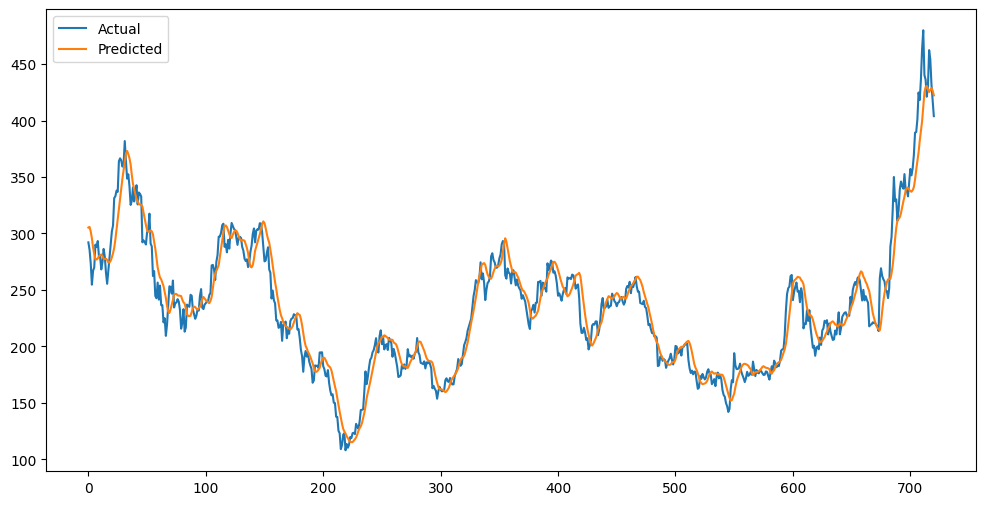

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_real, label="Actual")
plt.plot(pred_real, label="Predicted")

plt.legend()
plt.show()

## GRU

In [ ]:
model = Sequential()

model.add(GRU(64,return_sequences=True , input_shape=(x_train.shape[1],x_train.shape[2])))
model.add(Dropout(0.2))

model.add(GRU(32))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam',loss='mse')

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 30, 64)         │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,265 (90.88 KB)

 Trainable params: 23,265 (90.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(x_train,y_train,epochs=50,batch_size=32,validation_data=(x_test,y_test),callbacks=[early_stop])

Epoch 1/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0023 - val_loss: 0.0025
Epoch 2/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012 - val_loss: 0.0014
Epoch 3/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011 - val_loss: 0.0017
Epoch 4/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 9.0229e-04 - val_loss: 0.0037
Epoch 5/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.2482e-04 - val_loss: 9.3650e-04
Epoch 6/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.5907e-04 - val_loss: 9.5239e-04
Epoch 7/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.8241e-04 - val_loss: 9.2376e-04
Epoch 8/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.2565e-04 - val_loss: 0.0018
Epoch 9/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 7.3319e-04 - val_loss: 0.0012
Epoch 10/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.7664e-04 - val_loss: 0.0014
Epoch 11/50
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 4.4972e-04 - val_loss: 8.3419e-04
Epoch 12/50
91/91 ━━━━━

In [ ]:
prediction = model.predict(x_test)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


Inverse Scaling

In [ ]:
dummy = np.zeros((len(prediction), x.shape[2]))

dummy[:,0] = prediction.flatten()

pred_real = scaler.inverse_transform(dummy)[:,0]

In [ ]:
dummy2 = np.zeros((len(y_test), x.shape[2]))

dummy2[:,0] = y_test

y_real = scaler.inverse_transform(dummy2)[:,0]

Evalution of GRU

In [ ]:

rmse = np.sqrt(mean_squared_error(y_real, pred_real))
mae = mean_absolute_error(y_real, pred_real)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 11.298449229879527
MAE: 8.37731880518861


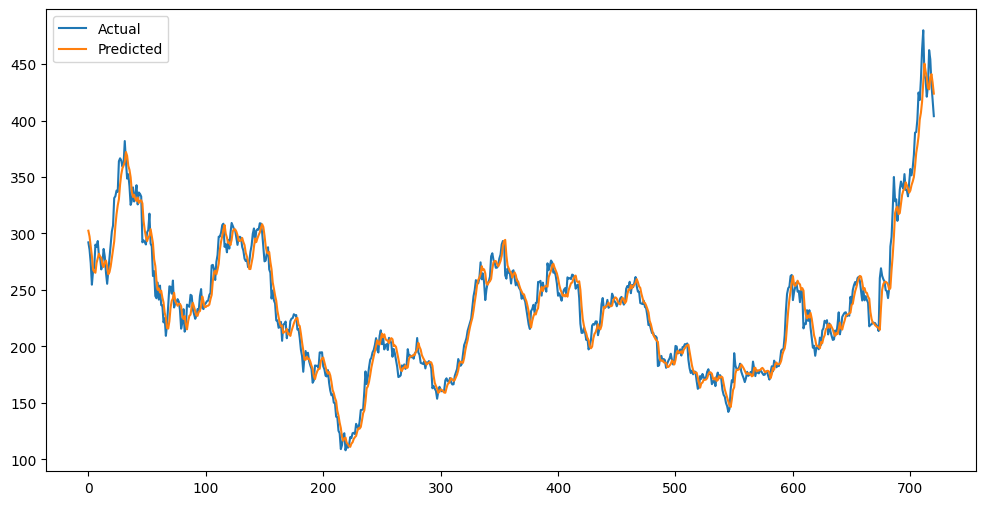

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(y_real, label="Actual")
plt.plot(pred_real, label="Predicted")

plt.legend()
plt.show()